In [ ]:
%pip install ucimlrepo pandas numpy seaborn matplotlib scikit-learn graphviz

In [1]:
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
import pandas as pd
import numpy as np
import graphviz
import multiprocessing

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [3]:
# Convert into a binary classifier
def LabelQuality(quality):
    if quality >= 7:
        return 1
    else:
        return 0

wine_df = pd.concat([wine_quality.data.features, wine_quality.data.targets], axis=1)
wine_df['good_quality'] = wine_df['quality'].apply(LabelQuality)
y = wine_df['good_quality']
print(wine_df['good_quality'].value_counts(normalize=True))
wine_df.describe()

good_quality
0    0.803448
1    0.196552
Name: proportion, dtype: float64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,good_quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.196552
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.397421
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [7]:
ada = AdaBoostClassifier(random_state=42)
clf = GridSearchCV(ada, {'n_estimators': [50, 100, 200], 'learning_rate': [1, 0.1, 0.01]}, verbose=1)
clf.fit(X, y)
print(clf.best_score_)
print(clf.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


C:\Users\2004t\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\2004t\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\2004t\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\2004t\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\200

0.8099117664475634
{'learning_rate': 0.1, 'n_estimators': 200}


In [9]:
# Compare the model's guesses against the actual labels
model = clf.best_estimator_
results_df = pd.DataFrame({'actual': y, 'predicted': model.predict(X)})
results_df['correct'] = results_df['actual'] == results_df['predicted']
print(results_df['correct'].value_counts(normalize=True))
results_df.head()

correct
True     0.823457
False    0.176543
Name: proportion, dtype: float64


,actual,predicted,correct
0,0,0,True
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True


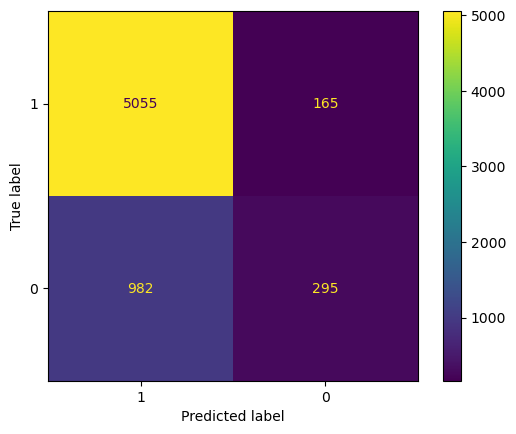

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay


conf = confusion_matrix(results_df['actual'], results_df['predicted'])
ConfusionMatrixDisplay(conf, display_labels=[1,0]).plot()
plt.show()

In [11]:
print(classification_report(results_df['actual'], results_df['predicted'], digits=4))

              precision    recall  f1-score   support

           0     0.8373    0.9684    0.8981      5220
           1     0.6413    0.2310    0.3397      1277

    accuracy                         0.8235      6497
   macro avg     0.7393    0.5997    0.6189      6497
weighted avg     0.7988    0.8235    0.7883      6497

